In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

In [2]:
data = {
    'Weather': ['Sunny', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Rainy'],
    'Activity': ['Go Out', 'Go Out', 'Go Out', 'Stay In', 'Stay In', 'Stay In']
}

df = pd.DataFrame(data)

print(df)

  Weather Activity
0   Sunny   Go Out
1   Sunny   Go Out
2   Sunny   Go Out
3   Rainy  Stay In
4   Rainy  Stay In
5   Rainy  Stay In


In [3]:
le_weather = LabelEncoder()
le_activity = LabelEncoder()

X = le_weather.fit_transform(df['Weather']).reshape(-1, 1)
y = le_activity.fit_transform(df['Activity'])

print("X:")
print(X)

print("y:")
print(y)

X:
[[1]
 [1]
 [1]
 [0]
 [0]
 [0]]
y:
[0 0 0 1 1 1]


In [4]:
model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=5
)

model.fit(X, y)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [5]:
weather = input("Enter weather (Sunny/Rainy): ")

weather_encoded = le_weather.transform([weather])

print("Encoded Weather:", weather_encoded)

Enter weather (Sunny/Rainy):  Sunny


Encoded Weather: [1]


In [6]:
prediction = model.predict([weather_encoded])

result = le_activity.inverse_transform(prediction)

print("Prediction:", result[0])

Prediction: Go Out


In [7]:
weather = input("Enter weather (Sunny/Rainy): ")

weather_encoded = le_weather.transform([weather])
prediction = model.predict([weather_encoded])
result = le_activity.inverse_transform(prediction)

print("Weather:", weather)
print("Decision:", result[0])

Enter weather (Sunny/Rainy):  Rainy


Weather: Rainy
Decision: Stay In


In [8]:
y_pred = model.predict(X)

print("Actual Values:   ", y)
print("Predicted Values:", y_pred)

Actual Values:    [0 0 0 1 1 1]
Predicted Values: [0 0 0 1 1 1]


In [9]:
from sklearn import metrics

conf_mat = metrics.confusion_matrix(y, y_pred)

print("Confusion Matrix:")
print(conf_mat)

accuracy = metrics.accuracy_score(y, y_pred)

print("Accuracy Score:", accuracy)
print("Accuracy in Percentage:", int(accuracy * 100), "%")

Confusion Matrix:
[[3 0]
 [0 3]]
Accuracy Score: 1.0
Accuracy in Percentage: 100 %


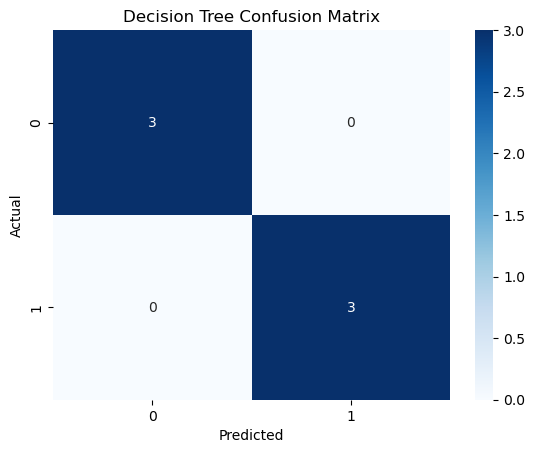

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    conf_mat,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()